# Multi-model ELI Skill & DJF Time Series

This notebook follows the figure structure in `3a_sst_skill_ts.ipynb`. It compares CESM-SMYLE and the E3SM systems using common target-year cohorts, then produces seasonal-by-initialization skill, overall monthly skill, and a 2-by-2 DJF time-series figure. ELI remains separate from rectangular SST indices because it is a longitude centroid with different units and interpretation.


In [97]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import subprocess
import re
import uuid
from pathlib import Path

import dask
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, VPacker, TextArea
from scipy.stats import pearsonr

from esp_lab import stats
from esp_lab import index_reference_skill
from esp_lab import eli_diagnostics as eli_tools
from esp_lab.utils import mov_utils as mov
from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

REPO_ROOT = Path(eli_tools.__file__).resolve().parents[1]
NATIVE_ELI_SCRIPT = REPO_ROOT / "scripts" / "run_process_native_eli.py"
if not NATIVE_ELI_SCRIPT.is_file():
    raise FileNotFoundError(f"Native ELI processor not found: {NATIVE_ELI_SCRIPT}")

# Resolve native-library paths from the active kernel.
_env_prefix = sys.prefix
_proj_path  = os.path.join(_env_prefix, "share", "proj")
if os.path.isfile(os.path.join(_proj_path, "proj.db")):
    os.environ["CONDA_PREFIX"] = _env_prefix
    os.environ["PROJ_LIB"]    = _proj_path
    os.environ["PROJ_DATA"]   = _proj_path
else:
    print("PROJ_LIB not set, proj.db not found.")

print(f"Python      : {sys.executable}")
print(f"CONDA_PREFIX: {os.environ.get('CONDA_PREFIX', '(not set)')}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python      : /global/homes/z/zhan391/.conda/envs/e3sm_analysis/bin/python
CONDA_PREFIX: /global/homes/z/zhan391/.conda/envs/e3sm_analysis


## Dask cluster

Create and own one cluster for lazy NetCDF reads, drift removal, and skill computation. Re-running this cell first closes resources left by the previous run, following the lifecycle used by `1a_atm_leadtime_acc_skill_map.ipynb`.


In [98]:
# Explicit per-notebook limits; DaskConfig also caps local shared nodes at four workers.
DASK_SETTINGS = {
    "enabled": True,
    "cluster_type": os.environ.get("CLUSTER_TYPE", "local"),
    "workers": 4,
    "cores": 1,
    "memory_limit": "4GB",
}
dask_cfg = DaskConfig(
    cluster_type=DASK_SETTINGS["cluster_type"],
    workers=DASK_SETTINGS["workers"],
    cores=DASK_SETTINGS["cores"],
    memory_limit=DASK_SETTINGS["memory_limit"],
    walltime="02:00:00",
)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(),
    lambda: get_cluster_client(dask_cfg) if DASK_SETTINGS["enabled"] else (None, None),
)
print(client)
print("xarray:", xr.__version__)
print("dask:", dask.__version__)



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Scheduler: tcp://127.0.0.1:37133
Connected workers: 4
Dashboard: http://127.0.0.1:8787/status
<Client: 'tcp://127.0.0.1:37133' processes=4 threads=4, memory=14.90 GiB>
xarray: 2026.4.0
dask: 2026.3.0


## Configuration

Edit the compact `WORKFLOW_SETTINGS` block below to select years, initialization months, ELI grid, paths, and models. Derived paths and model specifications are built automatically, following the centralized configuration pattern used by the 1a workflow. All configured model/month caches remain required so a comparison cannot silently omit a hindcast.


In [99]:
# User-facing workflow configuration. Later cells consume derived aliases.
INDEX = "ELI"
YEAR_END = 2011  # Set to None to use initialization_years[1].
climy0 = 1981
climy1 = 2010
init_months = [5, 11]
monthly_nlead = 24

WORKFLOW_SETTINGS = {
    "paths": {
        "diag_root": "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag",
        "figure_outdir": "/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag",
        "obs_eli_file": "/global/cfs/cdirs/e3sm/lvroekel/ELI_ERSSTv5_1854.01-2020.05.xlsx",
        "obs_eli_seasonal_file": "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/HadISST2/sst_index/timeseries/HadISST2_sst_ELI_seas.nc",
    },
    "run": {
        "initialization_years": (1980, 2018),
        "year_end": YEAR_END,
        "init_months": init_months,
        "climatology_years": (climy0, climy1),
    },
    "inputs": {
        "cache_mode": "auto",  # auto | require
        "cache_workers": 4,
        "eli_grid": "native",  # native | regridded
        "monthly_nlead": monthly_nlead,
        "seasonal_source_nlead": 8,
        "complete_seasonal_nlead": 7,
        "nmme_period": "1980_2020",
        # Keep leads independent while reductions span years and members.
        "chunks": {"Y": -1, "L": 1, "M": -1},
    },
    "models": {
        "CESM-SMYLE": {"label": "CESM-SMYLE", "cache_tag": "CESM-SMYLE", "ensemble_size": 20, "color": "tab:orange", "marker": "s", "family": "smyle"},
        "E3SM-FOSIRL": {"label": "E3SMv3-FOSIRL", "cache_tag": "JRA55_FOSIRL", "ensemble_size": 10, "color": "black", "marker": "o", "family": "e3sm"},
        "E3SM-Reanalysis": {"label": "E3SMv3-Reanalysis", "cache_tag": "Reanalysis", "ensemble_size": 10, "color": "tab:blue", "marker": "^", "family": "e3sm"},
        "E3SM-4DEnVarOcn": {"label": "E3SMv3-4DEnVarOcn", "cache_tag": "4DEnVarOcn", "ensemble_size": 10, "color": "tab:purple", "marker": "D", "family": "e3sm"},
    },
}

PATHS = WORKFLOW_SETTINGS["paths"]
RUN = WORKFLOW_SETTINGS["run"]
INPUTS = WORKFLOW_SETTINGS["inputs"]
DIAG_ROOT = Path(PATHS["diag_root"])
FIGURE_OUTDIR = Path(PATHS["figure_outdir"])
OBS_ELI_FILE = Path(PATHS["obs_eli_file"])
OBS_ELI_SEASONAL_FILE = Path(PATHS["obs_eli_seasonal_file"])
START_YEAR, configured_end_year = map(int, RUN["initialization_years"])
END_YEAR = configured_end_year if RUN["year_end"] is None else int(RUN["year_end"])
INIT_MONTHS = list(map(int, RUN["init_months"]))
CLIM_Y0, CLIM_Y1 = map(int, RUN["climatology_years"])
NLEAD = int(INPUTS["monthly_nlead"])
SEASONAL_SOURCE_NLEAD = int(INPUTS["seasonal_source_nlead"])
COMPLETE_SEASONAL_NLEAD = int(INPUTS["complete_seasonal_nlead"])
ELI_INPUT_GRID = str(INPUTS["eli_grid"])
NMME_PERIOD_TAG = str(INPUTS["nmme_period"])
ELI_CHUNKS = dict(INPUTS["chunks"])
ELI_CACHE_MODE = str(INPUTS["cache_mode"]).lower()
ELI_CACHE_WORKERS = int(INPUTS["cache_workers"])
if ELI_INPUT_GRID not in {"native", "regridded"}:
    raise ValueError("inputs.eli_grid must be 'native' or 'regridded'")
if ELI_CACHE_MODE not in {"auto", "require"}:
    raise ValueError("inputs.cache_mode must be 'auto' or 'require'")
if not START_YEAR <= END_YEAR <= configured_end_year:
    raise ValueError("run.year_end must lie within run.initialization_years")

NMME_OUTDIR = DIAG_ROOT / "NMME"
NMME_ELI_SKILL_FILE = NMME_OUTDIR / "sst_index" / "skill" / f"NMME_{INDEX}_skill_{NMME_PERIOD_TAG}.nc"
MULTIMODEL_ELI_DIR = DIAG_ROOT / "multimodel" / "eli"
for directory in (FIGURE_OUTDIR, MULTIMODEL_ELI_DIR):
    directory.mkdir(parents=True, exist_ok=True)
NMME_ELI_TIMESERIES_FILES = {
    month: NMME_OUTDIR / "sst_index" / "timeseries" / f"NMME{month:02d}_{INDEX}_mon_dd_{NMME_PERIOD_TAG}.nc"
    for month in INIT_MONTHS
}
NMME_ELI_SEASONAL_TIMESERIES_FILES = {
    month: NMME_OUTDIR / "sst_index" / "timeseries" / f"NMME{month:02d}_{INDEX}_seas_dd_{NMME_PERIOD_TAG}.nc"
    for month in INIT_MONTHS
}


e3sm_template = (
    f"E3SMLE{{init_month:02d}}_{INDEX}_native_N{{nens:02d}}_M{{nlead:02d}}.nc"
    if ELI_INPUT_GRID == "native"
    else f"E3SMLE{{init_month:02d}}_{INDEX}_N{{nens:02d}}_M{{nlead:02d}}.nc"
)
MODEL_SPECS = {
    key: eli_tools.ELIModelSpec(
        key=key,
        label=entry["label"],
        root=DIAG_ROOT / entry["cache_tag"] / "sst_index" / "timeseries",
        filename_template=(
            f"BSMYLE{{init_month:02d}}_{INDEX}_N{{nens:02d}}_M{{nlead:02d}}.nc"
            if entry["family"] == "smyle" else e3sm_template
        ),
        ensemble_size=int(entry["ensemble_size"]),
        color=entry["color"],
        marker=entry["marker"],
    )
    for key, entry in WORKFLOW_SETTINGS["models"].items()
}
SEASONAL_MODEL_SPECS = {
    key: eli_tools.ELIModelSpec(
        key=spec.key,
        label=spec.label,
        root=spec.root,
        filename_template=(
            spec.filename_template
            .replace("{nlead:02d}", f"{NLEAD:02d}")
            .replace(".nc", "_seas.nc")
        ),
        ensemble_size=spec.ensemble_size,
        color=spec.color,
        marker=spec.marker,
    )
    for key, spec in MODEL_SPECS.items()
}

# -----------------------------------------------------------------------------
# Figure configuration
# -----------------------------------------------------------------------------
MODEL_LINESTYLES = {model: ("-" if model == "CESM-SMYLE" else "-") for model in MODEL_SPECS}
NMME_STYLE = {"label": "NMME", "color": "tab:red", "linestyle": "-", "marker": "^", "spread_alpha": 0.18}

SKILL_PLOT_CONFIG = {
    "filename_parts": (INDEX, "multimodel", "acc_nrmse_skill"),
    "figfmt": "png",
    "dpi": 300,
    "font_size": 16,
    "title_font_scale": 1.00,
    "header_font_scale": 1.10,
    "tick_font_scale": 0.95,
    "legend_font_scale": 0.90,
    "line_width": 2.8,
    "marker_size_scale": 0.60,
    "significance_pval": 0.1,
    "hindcast_labels": {2: "FEB init", 5: "MAY init", 8: "AUG init", 11: "NOV init"},
    "all_init_label": "ALL init average",
    "season_labels_by_month": {
        5: ["JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF"],
        11: ["DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA"],
    },
    "seasonal_lead_offset": 2,
    "monthly_xticks": np.arange(1, NLEAD + 1, 2),
    "monthly_xticks_minor": np.arange(2, NLEAD + 1, 2),
    "monthly_xlim": [0.5, NLEAD + 0.5],
    "acc_ylim": [-0.3, 1.0],
    "seasonal_nrmse_ylim": [0.1, 1.5],
    "monthly_nrmse_ylim": [0.1, 1.5],
    "acc_reference": 0.5,
    "nrmse_reference": 1.0,
    "reference_color": "black",
    "ncol": 2,
    "fig_width": 16.0,
    "fig_height": 12.5,
    "acc_header": "Anomaly Correlation (ACC)",
    "nrmse_header": "Normalized RMSE (nRMSE)",
    "header_y": 0.945,
    "reference_line_width": 1,
    "show_grid": True,
    "acc_ylabel": "ACC",
    "nrmse_ylabel": "nRMSE",
    "xlabel": "Lead time (months)",
    "legend_loc": "lower center",
    "legend_bbox": (0.5, 0.015),
    "legend_facecolor": "#fcfcfc",
    "legend_edgecolor": "#d0d0d0",
    "legend_framealpha": 0.95,
    "legend_columnspacing": 1.0,
    "legend_handletextpad": 0.4,
    "layout_rect": [0.03, 0.09, 0.98, 0.94],
    "suptitle_y": 0.985,
    "metric": "eli_multimodel_skill",
    "title": f"{INDEX} Seasonal Skill Scores ({START_YEAR}-{END_YEAR})",
}

TIMESERIES_PLOT_CONFIG = {
    "filename_parts": (INDEX, "multimodel", "time_series"),
    "figfmt": "png",
    "dpi": 300,
    "plot_months": [11, 5],
    "target_leads": {11: [3, 15], 5: [9, 21]},
    "ncol": 2,
    "font_size": 16,
    "title_font_scale": 1.05,
    "tick_font_scale": 0.90,
    "legend_font_scale": 0.90,
    "annotation_font_scale": 0.68,
    "fig_width": 16.0,
    "fig_height": 8.5,
    "line_width": 2.6,
    "obs_color": "0.25",
    "obs_marker": ".",
    "obs_marker_size": 7,
    "spread_alpha": 0.10,
    "annotation_loc": "lower left",
    "annotation_bbox": (0.015, 0.035),
    "annotation_box": {"facecolor": "white", "edgecolor": "0.8", "alpha": 0.90},
    "plot_ylim": [-30, 35],
    "major_yticks": np.arange(-30, 36, 10),
    "minor_yticks": np.arange(-30, 36, 5),
    "major_year_step": 10,
    "minor_year_step": 5,
    "hindcast_labels": {5: "MAY", 11: "NOV"},
    "figlabs": [["(a)", "(b)"], ["(c)", "(d)"]],
    "minor_grid_alpha": 0.25,
    "show_major_grid": True,
    "axis_year_margin": 1,
    "ylabel": "ELI DJF anomaly (degE)",
    "xlabel": "Year",
    "legend_loc": "lower center",
    "legend_bbox": (0.5, 0.015),
    "legend_ncol": 4,
    "legend_facecolor": "#fcfcfc",
    "legend_edgecolor": "#d0d0d0",
    "legend_framealpha": 0.95,
    "layout_rect": [0.03, 0.10, 0.98, 0.94],
    "suptitle_y": 0.985,
    "metric": "eli_multimodel_time_series",
    "title": f"{INDEX} DJF Anomaly Time Series",
}

print(f"Evaluation years: {START_YEAR}-{END_YEAR}")
print(f"Climatology: {CLIM_Y0}-{CLIM_Y1}")
print(f"Initialization months: {INIT_MONTHS}")
print(f"ELI input grid: {ELI_INPUT_GRID}")
print("Models:", [spec.label for spec in MODEL_SPECS.values()])

Evaluation years: 1980-2011
Climatology: 1981-2010
Initialization months: [5, 11]
ELI input grid: native
Models: ['CESM-SMYLE', 'E3SMv3-FOSIRL', 'E3SMv3-Reanalysis', 'E3SMv3-4DEnVarOcn']


## Validate required inputs


In [100]:
if not OBS_ELI_FILE.is_file():
    raise FileNotFoundError(f"Observational ELI file not found: {OBS_ELI_FILE}")
if not OBS_ELI_SEASONAL_FILE.is_file():
    raise FileNotFoundError(f"Seasonal observational ELI file not found: {OBS_ELI_SEASONAL_FILE}")

required_model_files = {
    model: (
        [spec.path(month, NLEAD) for month in INIT_MONTHS]
        + [SEASONAL_MODEL_SPECS[model].path(month, SEASONAL_SOURCE_NLEAD) for month in INIT_MONTHS]
    )
    for model, spec in MODEL_SPECS.items()
}
missing_by_model = {
    model: [path for path in paths if not path.is_file()]
    for model, paths in required_model_files.items()
}
missing_by_model = {model: paths for model, paths in missing_by_model.items() if paths}

# Native E3SM ELI caches are reusable preprocessing products. In auto mode,
# generate only cases with missing files; require mode remains read-only.
missing_e3sm_cases = [
    WORKFLOW_SETTINGS["models"][model]["cache_tag"]
    for model in missing_by_model
    if WORKFLOW_SETTINGS["models"][model]["family"] == "e3sm"
]
if missing_e3sm_cases and ELI_CACHE_MODE == "auto":
    command = [
        sys.executable, str(NATIVE_ELI_SCRIPT),
        "--cases", *missing_e3sm_cases,
        "--outdir", str(DIAG_ROOT),
        "--init-months", *map(str, INIT_MONTHS),
        "--year-start", str(START_YEAR),
        "--year-end", str(END_YEAR),
        "--nlead", str(NLEAD),
        "--e3sm-nens", "10",
        "--workers", str(ELI_CACHE_WORKERS),
    ]
    print("Preparing missing native ELI caches for:", missing_e3sm_cases)
    subprocess.run(command, check=True)

missing_model_files = [
    path for paths in required_model_files.values() for path in paths
    if not path.is_file()
]
if missing_model_files:
    raise FileNotFoundError(
        f"Missing required ELI caches after inputs.cache_mode={ELI_CACHE_MODE!r}:\n" +
        "\n".join(f"  {path}" for path in missing_model_files)
    )

NMME_ELI_SKILL_AVAILABLE = NMME_ELI_SKILL_FILE.is_file()
nmme_skill_plot = None
nmme_skill_spread = None
nmme_seas_skill_plot = None
nmme_seas_skill_spread = None
if NMME_ELI_SKILL_AVAILABLE:
    nmme_eli_skill = workflow_resources.track(
        xr.open_dataset(NMME_ELI_SKILL_FILE, chunks="auto")
    )
    nmme_skill_plot = xr.Dataset({
        "acc": nmme_eli_skill["nmme_skill_mmm_corr"],
        "pval": nmme_eli_skill["nmme_skill_mmm_pval"],
        # The archived NMME `rmse` follows the Yeager normalized-RMSE convention.
        "nrmse": nmme_eli_skill["nmme_skill_mmm_rmse"],
    }).rename({"monthly_L": "L"})
    nmme_skill_spread = xr.Dataset({
        "acc": nmme_eli_skill["nmme_skill_corr"],
        "nrmse": nmme_eli_skill["nmme_skill_rmse"],
    }).rename({"monthly_L": "L"})
    nmme_seas_skill_plot = xr.Dataset({
        "acc": nmme_eli_skill["nmme_seas_skill_mmm_corr"],
        "pval": nmme_eli_skill["nmme_seas_skill_mmm_pval"],
        "nrmse": nmme_eli_skill["nmme_seas_skill_mmm_rmse"],
    }).rename({"seasonal_L": "L"})
    nmme_seas_skill_spread = xr.Dataset({
        "acc": nmme_eli_skill["nmme_seas_skill_corr"],
        "nrmse": nmme_eli_skill["nmme_seas_skill_rmse"],
    }).rename({"seasonal_L": "L"})
NMME_ELI_TIMESERIES_AVAILABLE = all(path.is_file() for path in NMME_ELI_TIMESERIES_FILES.values())
nmme_eli_timeseries = {}
if NMME_ELI_TIMESERIES_AVAILABLE:
    for month, path in NMME_ELI_TIMESERIES_FILES.items():
        ds = workflow_resources.track(xr.open_dataset(path, chunks="auto"))
        ds = ds.sel(Y=slice(START_YEAR, END_YEAR))
        nmme_eli_timeseries[month] = {"values": ds["sst"], "time": ds["time"]}
NMME_ELI_SEASONAL_TIMESERIES_AVAILABLE = all(
    path.is_file() for path in NMME_ELI_SEASONAL_TIMESERIES_FILES.values()
)
nmme_eli_seas_timeseries = {}
if NMME_ELI_SEASONAL_TIMESERIES_AVAILABLE:
    for month, path in NMME_ELI_SEASONAL_TIMESERIES_FILES.items():
        ds = workflow_resources.track(xr.open_dataset(path, chunks="auto"))
        ds = ds.sel(Y=slice(START_YEAR, END_YEAR))
        nmme_eli_seas_timeseries[month] = {"values": ds["sst"], "time": ds["time"]}
print("Configuration valid")
for model, paths in required_model_files.items():
    print(f"  {MODEL_SPECS[model].label}:")
    for path in paths:
        print(f"    {path.name}")
print(f"  NMME skill available: {NMME_ELI_SKILL_AVAILABLE}")
print(f"  NMME monthly time series available: {NMME_ELI_TIMESERIES_AVAILABLE}")
print(f"  NMME seasonal time series available: {NMME_ELI_SEASONAL_TIMESERIES_AVAILABLE}")


Configuration valid
  CESM-SMYLE:
    BSMYLE05_ELI_N20_M24.nc
    BSMYLE11_ELI_N20_M24.nc
    BSMYLE05_ELI_N20_M24_seas.nc
    BSMYLE11_ELI_N20_M24_seas.nc
  E3SMv3-FOSIRL:
    E3SMLE05_ELI_native_N10_M24.nc
    E3SMLE11_ELI_native_N10_M24.nc
    E3SMLE05_ELI_native_N10_M24_seas.nc
    E3SMLE11_ELI_native_N10_M24_seas.nc
  E3SMv3-Reanalysis:
    E3SMLE05_ELI_native_N10_M24.nc
    E3SMLE11_ELI_native_N10_M24.nc
    E3SMLE05_ELI_native_N10_M24_seas.nc
    E3SMLE11_ELI_native_N10_M24_seas.nc
  E3SMv3-4DEnVarOcn:
    E3SMLE05_ELI_native_N10_M24.nc
    E3SMLE11_ELI_native_N10_M24.nc
    E3SMLE05_ELI_native_N10_M24_seas.nc
    E3SMLE11_ELI_native_N10_M24_seas.nc
  NMME skill available: True
  NMME monthly time series available: True
  NMME seasonal time series available: True


## 1.  Load observational ELI

The Excel file contains a monthly ELI time series derived from ERSSTv5.
Each column header is a year; each row is a calendar month (0-indexed).
Values are converted to an `xarray.DataArray` with a monthly time axis.

In [101]:
df_obs = pd.read_excel(OBS_ELI_FILE)

# Collect all available years in column order.
obs_years = [c for c in df_obs.columns if isinstance(c, (int, np.integer))]

times_obs    = []
eli_obs_vals = []
for yr in obs_years:
    for mo in range(12):
        val = df_obs[yr].iloc[mo]
        times_obs.append(pd.Timestamp(year=int(yr), month=mo + 1, day=1))
        eli_obs_vals.append(float(val) if pd.notna(val) else np.nan)

obs_time = pd.DatetimeIndex(times_obs)
eli_obs = xr.DataArray(
    np.array(eli_obs_vals, dtype=np.float32),
    dims="time",
    coords={"time": obs_time},
    name="eli_obs",
    attrs={
        "long_name": "Observed Equatorial Longitude Index (ERSSTv5)",
        "units": "degrees_east",
        "source": str(OBS_ELI_FILE),
    },
)

# Clip to model verification period (with buffer for drift removal).
eli_obs = eli_obs.sel(time=slice(str(START_YEAR - 2), str(END_YEAR + 2)))

# Monthly climatology over the base period for anomaly computation.
obs_clim_mask = (
    (eli_obs.time.dt.year >= CLIM_Y0) &
    (eli_obs.time.dt.year <= CLIM_Y1)
)
obs_clim = eli_obs.isel(time=obs_clim_mask).groupby("time.month").mean()

eli_obs_anom = eli_obs.groupby("time.month") - obs_clim
eli_obs_anom.name = "eli_obs_anom"
eli_obs_anom.attrs = {
    "long_name": "Observed ELI anomaly (ERSSTv5)",
    "units": "degrees_east",
}

# Seasonal ELI is computed upstream from centered three-month SST fields.
# Use that product rather than averaging the nonlinear monthly ELI values.
with xr.open_dataset(OBS_ELI_SEASONAL_FILE) as seasonal_obs_ds:
    eli_obs_seas = seasonal_obs_ds["eli"].load()
eli_obs_seas = eli_obs_seas.sel(time=slice(str(START_YEAR - 2), str(END_YEAR + 2)))
seasonal_obs_clim_mask = (
    (eli_obs_seas.time.dt.year >= CLIM_Y0)
    & (eli_obs_seas.time.dt.year <= CLIM_Y1)
)
seasonal_obs_clim = eli_obs_seas.isel(time=seasonal_obs_clim_mask).groupby("time.month").mean()
eli_obs_seas_anom = eli_obs_seas.groupby("time.month") - seasonal_obs_clim
eli_obs_seas_anom.name = "eli_obs_seas_anom"

print(f"Observational ELI: {len(eli_obs)} months")
print(f"  period : {str(eli_obs.time.values[0])[:10]} — {str(eli_obs.time.values[-1])[:10]}")
print(f"  min/max: {float(eli_obs.min()):.2f} / {float(eli_obs.max()):.2f}°E")
print(f"  mean   : {float(eli_obs.mean()):.2f}°E")
print(f"\nObs anomaly std : {float(eli_obs_anom.std()):.2f}°E")

Observational ELI: 432 months
  period : 1978-01-01 — 2013-12-01
  min/max: 143.92 / 222.66°E
  mean   : 162.51°E

Obs anomaly std : 9.49°E


## 2. Load CESM-SMYLE and both E3SM hindcasts


In [102]:
eli_model, eli_time, eli_provenance = eli_tools.load_model_hindcasts(
    MODEL_SPECS,
    INIT_MONTHS,
    nlead=NLEAD,
    start_year=START_YEAR,
    end_year=END_YEAR,
    chunks=ELI_CHUNKS,
    resource_tracker=workflow_resources,
)
eli_seas_model, eli_seas_time, eli_seas_provenance = eli_tools.load_model_hindcasts(
    SEASONAL_MODEL_SPECS,
    INIT_MONTHS,
    nlead=SEASONAL_SOURCE_NLEAD,
    start_year=START_YEAR,
    end_year=END_YEAR,
    chunks=ELI_CHUNKS,
    resource_tracker=workflow_resources,
)
for model in MODEL_SPECS:
    for month in INIT_MONTHS:
        seasonal_data, seasonal_time, dropped = index_reference_skill.retain_complete_seasonal_leads(
            eli_seas_model[model][month],
            eli_seas_time[model][month],
            label=f"{MODEL_SPECS[model].label} init {month:02d}",
            expected_count=COMPLETE_SEASONAL_NLEAD,
        )
        eli_seas_model[model][month] = seasonal_data
        eli_seas_time[model][month] = seasonal_time
        if dropped:
            print(f"Dropped incomplete seasonal leads for {model} init {month:02d}: {dropped}")

for model, spec in MODEL_SPECS.items():
    for month in INIT_MONTHS:
        values = eli_model[model][month]
        print(
            f"{spec.label}, init {month:02d}: sizes={dict(values.sizes)}, "
            f"finite={float(values.notnull().mean()):.3f}, "
            f"range={float(values.min()):.2f}-{float(values.max()):.2f} degE"
        )


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/eli_diagnostics.py:83: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  source = xr.open_dataset(path, chunks=chunks)
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/eli_diagnostics.py:83: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  source = xr.open_dataset(path, chunks=chunks)
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/eli_diagnostics.py:83: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  source = xr.open_dataset(path, chunks=chunks)
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/eli_diagnostics.py:83: UserWarning: The specified chunks separate the stored chunks a

Dropped incomplete seasonal leads for CESM-SMYLE init 05: [24]
Dropped incomplete seasonal leads for CESM-SMYLE init 11: [24]
Dropped incomplete seasonal leads for E3SM-FOSIRL init 05: [24]
Dropped incomplete seasonal leads for E3SM-FOSIRL init 11: [24]
Dropped incomplete seasonal leads for E3SM-Reanalysis init 05: [24]
Dropped incomplete seasonal leads for E3SM-Reanalysis init 11: [24]
Dropped incomplete seasonal leads for E3SM-4DEnVarOcn init 05: [24]
Dropped incomplete seasonal leads for E3SM-4DEnVarOcn init 11: [24]
CESM-SMYLE, init 05: sizes={'Y': 32, 'L': 24, 'M': 20}, finite=1.000, range=139.71-203.67 degE
CESM-SMYLE, init 11: sizes={'Y': 32, 'L': 24, 'M': 20}, finite=1.000, range=140.52-220.53 degE
E3SMv3-FOSIRL, init 05: sizes={'Y': 32, 'L': 24, 'M': 10}, finite=1.000, range=137.23-196.19 degE
E3SMv3-FOSIRL, init 11: sizes={'Y': 32, 'L': 24, 'M': 10}, finite=1.000, range=136.04-200.44 degE
E3SMv3-Reanalysis, init 05: sizes={'Y': 32, 'L': 24, 'M': 10}, finite=1.000, range=140.0

## 3. Lead-dependent drift removal

Each model uses its own 1981–2010 ensemble climatology at every lead. This removes model drift while preserving a common verification cohort for the later comparison.


In [103]:
eli_dd, eli_drift = eli_tools.remove_lead_drift(
    eli_model,
    clim_start=CLIM_Y0,
    clim_end=CLIM_Y1,
)
eli_seas_dd, eli_seas_drift = eli_tools.remove_lead_drift(
    eli_seas_model,
    clim_start=CLIM_Y0,
    clim_end=CLIM_Y1,
)

# Drift anomalies are reused for cohort selection, skill, and plotting.
# Persist once so those consumers share the distributed result.
if client is not None:
    persisted_keys = [
        (model, month) for model in MODEL_SPECS for month in INIT_MONTHS
    ]
    persisted_values = client.persist([
        eli_dd[model][month] for model, month in persisted_keys
    ] + [
        eli_seas_dd[model][month] for model, month in persisted_keys
    ])
    monthly_persisted = persisted_values[:len(persisted_keys)]
    seasonal_persisted = persisted_values[len(persisted_keys):]
    for (model, month), values in zip(persisted_keys, monthly_persisted):
        eli_dd[model][month] = values
    for (model, month), values in zip(persisted_keys, seasonal_persisted):
        eli_seas_dd[model][month] = values
    from dask.distributed import wait
    wait(persisted_values)

for model, spec in MODEL_SPECS.items():
    for month in INIT_MONTHS:
        drift = eli_drift[model][month]
        print(
            f"{spec.label}, init {month:02d}: drift "
            f"{float(drift.min()):.2f}-{float(drift.max()):.2f} degE"
        )


CESM-SMYLE, init 05: drift 149.90-172.16 degE
CESM-SMYLE, init 11: drift 151.59-167.57 degE
E3SMv3-FOSIRL, init 05: drift 144.91-169.32 degE
E3SMv3-FOSIRL, init 11: drift 146.36-170.32 degE
E3SMv3-Reanalysis, init 05: drift 152.23-172.06 degE
E3SMv3-Reanalysis, init 11: drift 151.58-171.59 degE
E3SMv3-4DEnVarOcn, init 05: drift 153.75-174.58 degE
E3SMv3-4DEnVarOcn, init 11: drift 156.11-175.12 degE


## 4. Common-cohort skill computation

ACC, p values, RMSE, and normalized RMSE are calculated on the intersection of valid target years across CESM-SMYLE, both E3SM hindcasts, and ERSSTv5 independently for every initialization month and lead.


In [104]:
skill, common_target_years = eli_tools.compute_multimodel_skill(
    eli_dd,
    eli_time,
    eli_obs_anom,
    INIT_MONTHS,
)
seasonal_skill, seasonal_common_target_years = eli_tools.compute_multimodel_skill(
    eli_seas_dd,
    eli_seas_time,
    eli_obs_seas_anom,
    INIT_MONTHS,
)

for month in INIT_MONTHS:
    print(
        f"Common samples, init {month:02d}:",
        {
            lead: (years[0], years[-1], len(years))
            for lead, years in common_target_years[month].items()
        },
    )
    print(
        f"Common seasonal samples, init {month:02d}:",
        {
            lead: (years[0], years[-1], len(years))
            for lead, years in seasonal_common_target_years[month].items()
        },
    )

model_coord = xr.DataArray(list(MODEL_SPECS), dims="model", name="model")
startmonth_coord = xr.DataArray(INIT_MONTHS, dims="startmonth", name="startmonth")
skill_dataset = xr.concat(
    [
        xr.concat(
            [skill[model][month] for month in INIT_MONTHS],
            dim=startmonth_coord,
            join="exact",
        )
        for model in MODEL_SPECS
    ],
    dim=model_coord,
    join="exact",
)
skill_dataset.attrs = {}
skill_dataset.attrs.update(
    description="CESM-SMYLE and two E3SM hindcast ELI skill on common target-year cohorts",
    verification_initialization_years=f"{START_YEAR}-{END_YEAR}",
    climatology=f"{CLIM_Y0}-{CLIM_Y1}",
    sample_alignment="intersection across all compared models and ERSSTv5 independently by initialization and lead",
    models=",".join(MODEL_SPECS),
    eli_input_grid=ELI_INPUT_GRID,
)
skill_file = MULTIMODEL_ELI_DIR / f"eli_multimodel_skill_{START_YEAR}_{END_YEAR}.nc"
temporary = skill_file.with_name(f".{skill_file.name}.tmp.{uuid.uuid4().hex}")
try:
    skill_dataset.to_netcdf(temporary)
    os.replace(temporary, skill_file)
finally:
    temporary.unlink(missing_ok=True)
print("Saved:", skill_file)
display(skill_dataset)


Common samples, init 05: {1: (1980, 2011, 32), 2: (1980, 2011, 32), 3: (1980, 2011, 32), 4: (1980, 2011, 32), 5: (1980, 2011, 32), 6: (1980, 2011, 32), 7: (1980, 2011, 32), 8: (1980, 2011, 32), 9: (1981, 2012, 32), 10: (1981, 2012, 32), 11: (1981, 2012, 32), 12: (1981, 2012, 32), 13: (1981, 2012, 32), 14: (1981, 2012, 32), 15: (1981, 2012, 32), 16: (1981, 2012, 32), 17: (1981, 2012, 32), 18: (1981, 2012, 32), 19: (1981, 2012, 32), 20: (1981, 2012, 32), 21: (1982, 2013, 32), 22: (1982, 2013, 32), 23: (1982, 2013, 32), 24: (1982, 2013, 32)}
Common seasonal samples, init 05: {3: (1980, 2011, 32), 6: (1980, 2011, 32), 9: (1981, 2012, 32), 12: (1981, 2012, 32), 15: (1981, 2012, 32), 18: (1981, 2012, 32), 21: (1982, 2013, 32)}
Common samples, init 11: {1: (1980, 2011, 32), 2: (1980, 2011, 32), 3: (1981, 2012, 32), 4: (1981, 2012, 32), 5: (1981, 2012, 32), 6: (1981, 2012, 32), 7: (1981, 2012, 32), 8: (1981, 2012, 32), 9: (1981, 2012, 32), 10: (1981, 2012, 32), 11: (1981, 2012, 32), 12: (1981,

<xarray.Dataset> Size: 11kB
Dimensions:            (model: 4, startmonth: 2, L: 24)
Coordinates:
  * model              (model) <U15 240B 'CESM-SMYLE' ... 'E3SM-4DEnVarOcn'
  * startmonth         (startmonth) int64 16B 5 11
  * L                  (L) int64 192B 1 2 3 4 5 6 7 8 ... 18 19 20 21 22 23 24
Data variables:
    acc                (model, startmonth, L) float64 2kB 0.8184 ... -0.03825
    pval               (model, startmonth, L) float64 2kB 1.054e-08 ... 0.8354
    rmse               (model, startmonth, L) float64 2kB 5.586 4.196 ... 6.746
    nrmse              (model, startmonth, L) float64 2kB 0.6271 ... 1.119
    sample_count       (model, startmonth, L) int64 2kB 32 32 32 32 ... 32 32 32
    target_year_start  (model, startmonth, L) int64 2kB 1980 1980 ... 1982 1982
    target_year_end    (model, startmonth, L) int64 2kB 2011 2011 ... 2013 2013
Attributes:
    description:                        CESM-SMYLE and two E3SM hindcast ELI ...
    verification_initialization_years:  1980-2011
    climatology:                        1981-2010
    sample_alignment:                   intersection across all compared mode...
    models:                             CESM-SMYLE,E3SM-FOSIRL,E3SM-Reanalysi...
    eli_input_grid:                     native

## 5. Multi-model ACC and normalized-RMSE skill

This follows the skill-figure layout in `3a_sst_skill_ts.ipynb`: one seasonal row per initialization month, followed by the monthly all-initialization mean. Filled ACC markers indicate `p < 0.1`; open markers show the remaining leads. CESM-SMYLE and the three E3SM systems use the same target-year cohort at each initialization and lead. The red NMME benchmark and its across-model range come from the archived 1980–2020 NMME ELI skill product.


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_eli_multimodel_acc_nrmse_skill.png


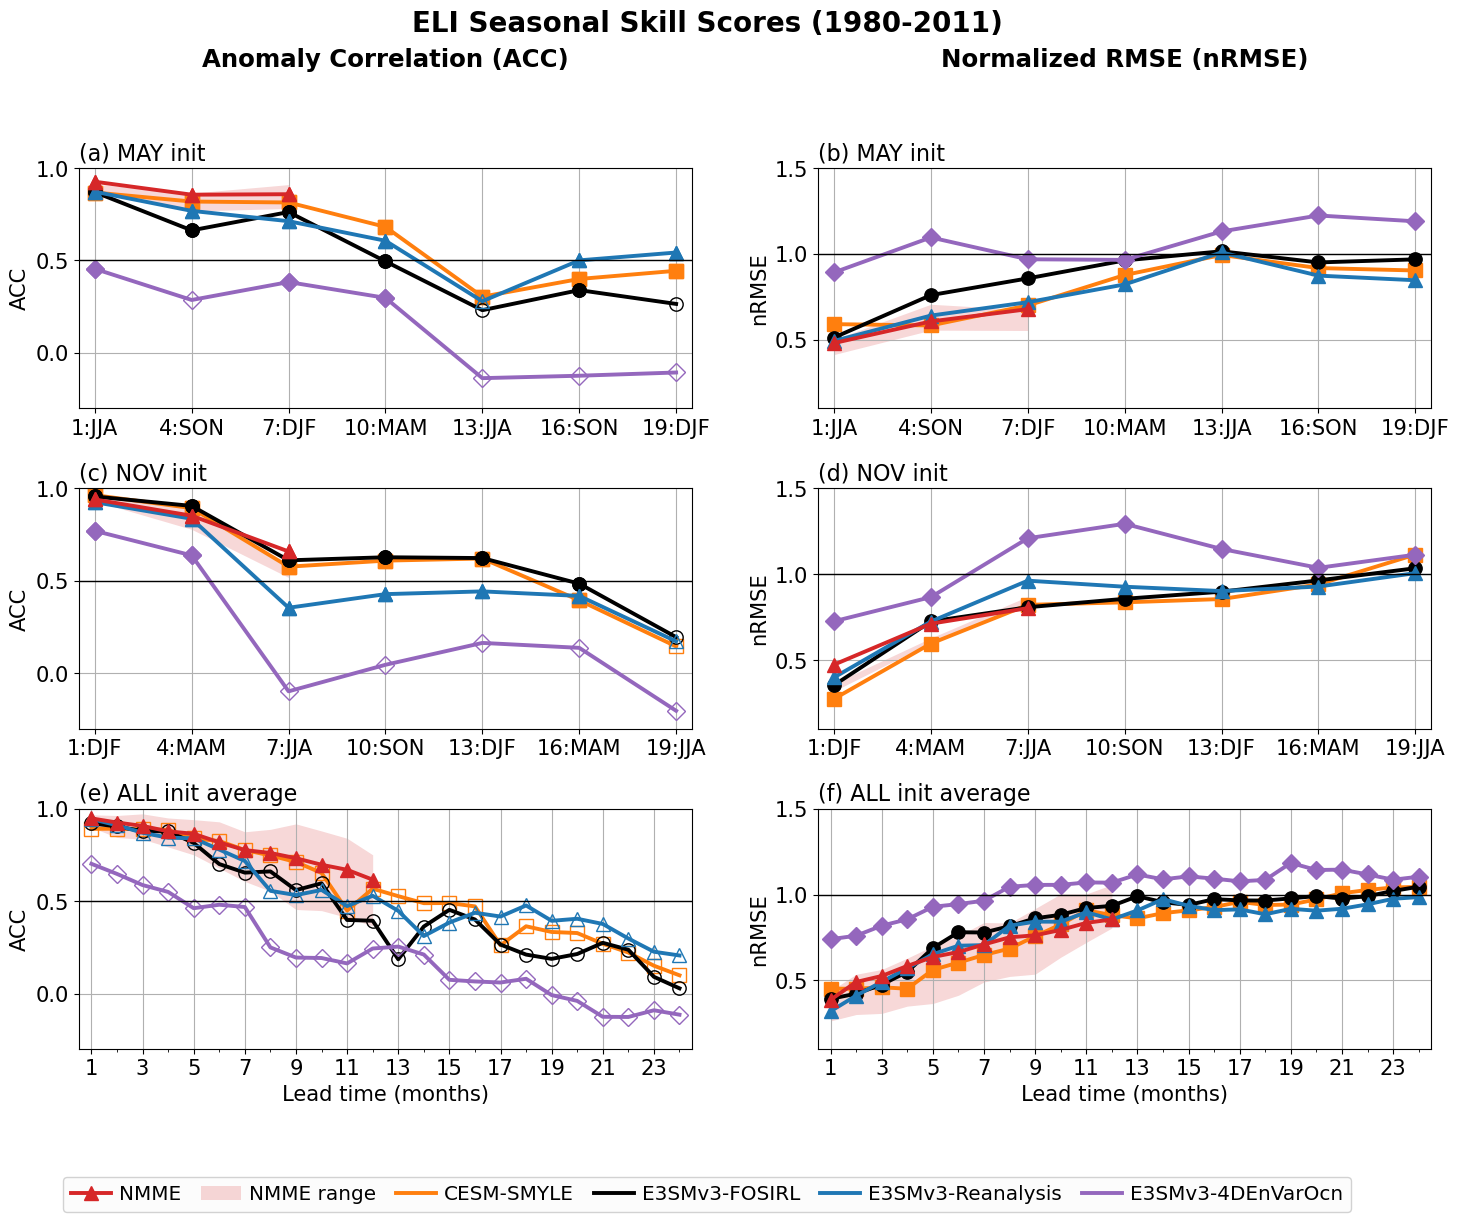

In [105]:

def figure_filename(*parts, ext="png"):
    clean = ["fig"]
    for part in parts:
        token = re.sub(r"[^A-Za-z0-9]+", "_", str(part).strip()).strip("_").lower()
        if token:
            clean.append(token)
    return "_".join(clean) + f".{ext.lstrip('.')}"

# -----------------------------
# Plot seasonal skill by initialization and overall monthly skill
# -----------------------------
plot_cfg = SKILL_PLOT_CONFIG
nmme_style = NMME_STYLE
figname = figure_filename(*plot_cfg["filename_parts"], ext=plot_cfg["figfmt"])
fontz = plot_cfg["font_size"]
title_fontz = fontz * plot_cfg["title_font_scale"]
header_fontz = fontz * plot_cfg["header_font_scale"]
tick_fontz = fontz * plot_cfg["tick_font_scale"]
legend_fontz = fontz * plot_cfg["legend_font_scale"]
line_width = plot_cfg["line_width"]
marker_size = fontz * plot_cfg["marker_size_scale"]

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})

nrow, ncol = len(INIT_MONTHS) + 1, plot_cfg["ncol"]
fig_width = plot_cfg["fig_width"]
fig_height = plot_cfg["fig_height"]
fig = plt.figure(figsize=(fig_width, fig_height))
figlabs = [f"({chr(97 + i)})" for i in range(nrow * ncol)]
top_axes = []

monthly_skill_by_model = {
    model: xr.concat(
        [skill[model][month] for month in INIT_MONTHS],
        dim=xr.DataArray(INIT_MONTHS, dims="startmonth", name="startmonth"),
        join="exact",
    )
    for model in MODEL_SPECS
}

for row, month in enumerate(INIT_MONTHS + [None]):
    ax = fig.add_subplot(nrow, ncol, row * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, row * 2 + 2)
    if row == 0:
        top_axes = [ax, ax2]
    row_label = plot_cfg["all_init_label"] if month is None else plot_cfg["hindcast_labels"].get(month, f"{month:02d} init")
    ax.set_title(f"{figlabs[row * 2]} {row_label}", loc="left", fontsize=title_fontz)
    ax2.set_title(f"{figlabs[row * 2 + 1]} {row_label}", loc="left", fontsize=title_fontz)
    for model, spec in MODEL_SPECS.items():
        scores = (
            monthly_skill_by_model[model].mean("startmonth")
            if month is None else seasonal_skill[model][month]
        )
        x = scores.L if month is None else scores.L - plot_cfg["seasonal_lead_offset"]
        linestyle = MODEL_LINESTYLES[model]

        ax.plot(
            x, scores.acc,
            color=spec.color,
            linewidth=line_width,
            linestyle=linestyle,
            label=spec.label,
        )
        ax.plot(
            x, scores.acc,
            color=spec.color,
            linestyle="none",
            marker=spec.marker,
            markerfacecolor="none",
            markersize=marker_size,
        )
        # A mean p value is not a valid all-init significance test, so only
        # initialization-specific rows receive filled significance markers.
        if month is not None:
            ax.plot(
                x, scores.acc.where(scores.pval < plot_cfg["significance_pval"]),
                color=spec.color,
                linestyle="none",
                marker=spec.marker,
                markersize=marker_size,
            )

        ax2.plot(
            x, scores.nrmse,
            color=spec.color,
            linewidth=line_width,
            linestyle=linestyle,
            marker=spec.marker,
            markersize=marker_size,
            label=spec.label,
        )

    if month is None:
        nmme_scores = (
            nmme_skill_plot.mean("startmonth")
            if nmme_skill_plot is not None else None
        )
        nmme_range = nmme_skill_spread
        spread_dims = (
            [dim for dim in ("startmonth", "model") if dim in nmme_range.dims]
            if nmme_range is not None else []
        )
    elif nmme_seas_skill_plot is not None and month in nmme_seas_skill_plot.startmonth.values:
        nmme_scores = nmme_seas_skill_plot.sel(startmonth=month)
        nmme_range = nmme_seas_skill_spread.sel(startmonth=month)
        spread_dims = [dim for dim in ("model",) if dim in nmme_range.dims]
    else:
        nmme_scores = None

    if nmme_scores is not None:
            x_nmme = (
                nmme_scores.L if month is None
                else nmme_scores.L - plot_cfg["seasonal_lead_offset"]
            )
            ax.fill_between(
                x_nmme,
                nmme_range.acc.min(spread_dims, skipna=True),
                nmme_range.acc.max(spread_dims, skipna=True),
                color=nmme_style["color"], alpha=nmme_style["spread_alpha"], linewidth=0,
            )
            ax2.fill_between(
                x_nmme,
                nmme_range.nrmse.min(spread_dims, skipna=True),
                nmme_range.nrmse.max(spread_dims, skipna=True),
                color=nmme_style["color"], alpha=nmme_style["spread_alpha"], linewidth=0,
            )
            ax.plot(
                x_nmme, nmme_scores.acc,
                color=nmme_style["color"], linewidth=line_width, linestyle=nmme_style["linestyle"],
                marker=nmme_style["marker"], markersize=marker_size, label=nmme_style["label"],
            )
            if month is not None:
                ax.plot(
                    x_nmme, nmme_scores.acc.where(nmme_scores.pval < plot_cfg["significance_pval"]),
                    color=nmme_style["color"], linestyle="none", marker=nmme_style["marker"],
                    markersize=marker_size,
                )
            ax2.plot(
                x_nmme, nmme_scores.nrmse,
                color=nmme_style["color"], linewidth=line_width, linestyle=nmme_style["linestyle"],
                marker=nmme_style["marker"], markersize=marker_size, label=nmme_style["label"],
            )

    nrmse_ylim = (
        plot_cfg["monthly_nrmse_ylim"]
        if month is None else plot_cfg["seasonal_nrmse_ylim"]
    )
    for panel, ylim, reference in ((ax, plot_cfg["acc_ylim"], plot_cfg["acc_reference"]), (ax2, nrmse_ylim, plot_cfg["nrmse_reference"])):
        if month is None:
            panel.set_xticks(plot_cfg["monthly_xticks"])
            panel.set_xticks(plot_cfg["monthly_xticks_minor"], minor=True)
            panel.set_xlim(plot_cfg["monthly_xlim"])
        else:
            seasonal_leads = (
                seasonal_skill[next(iter(MODEL_SPECS))][month].L
                - plot_cfg["seasonal_lead_offset"]
            )
            season_names = plot_cfg["season_labels_by_month"][month]
            panel.set_xticks(seasonal_leads)
            panel.set_xticklabels([
                f"{int(lead)}:{season}"
                for lead, season in zip(seasonal_leads.values, season_names)
            ])
            panel.set_xlim(float(seasonal_leads.min()) - 0.5, float(seasonal_leads.max()) + 0.5)
        panel.set_ylim(ylim)
        panel.tick_params(axis="both", labelsize=tick_fontz)
        panel.grid(plot_cfg["show_grid"])
        panel.axhline(reference, color=plot_cfg["reference_color"], linewidth=plot_cfg["reference_line_width"])

    ax.set_ylabel(plot_cfg["acc_ylabel"], fontsize=tick_fontz)
    ax2.set_ylabel(plot_cfg["nrmse_ylabel"], fontsize=tick_fontz)
    if row == nrow - 1:
        ax.set_xlabel(plot_cfg["xlabel"], fontsize=tick_fontz)
        ax2.set_xlabel(plot_cfg["xlabel"], fontsize=tick_fontz)

handles, labels = fig.axes[0].get_legend_handles_labels()
if nmme_skill_spread is not None and nmme_style["label"] in labels:
    handles.append(mpatches.Patch(facecolor=nmme_style["color"], alpha=nmme_style["spread_alpha"], linewidth=0))
    labels.append("NMME range")
legend_items = {label: handle for handle, label in zip(handles, labels) if label}
preferred_labels = [nmme_style["label"], "NMME range"] + [
    spec.label for spec in MODEL_SPECS.values()
]
labels = [label for label in preferred_labels if label in legend_items]
handles = [legend_items[label] for label in labels]
fig.legend(
    handles, labels,
    loc=plot_cfg["legend_loc"],
    ncol=len(labels),
    bbox_to_anchor=plot_cfg["legend_bbox"],
    frameon=True,
    facecolor=plot_cfg["legend_facecolor"],
    edgecolor=plot_cfg["legend_edgecolor"],
    framealpha=plot_cfg["legend_framealpha"],
    fontsize=legend_fontz,
    columnspacing=plot_cfg["legend_columnspacing"],
    handletextpad=plot_cfg["legend_handletextpad"],
)
fig.suptitle(
    plot_cfg["title"],
    fontsize=fontz * 1.25,
    fontweight="bold",
    y=plot_cfg["suptitle_y"],
)
fig.tight_layout(rect=plot_cfg["layout_rect"])
for axis, header in zip(top_axes, (plot_cfg["acc_header"], plot_cfg["nrmse_header"])):
    position = axis.get_position()
    fig.text(
        position.x0 + 0.5 * position.width, plot_cfg["header_y"], header,
        ha="center", va="center", fontsize=header_fontz, fontweight="bold",
    )
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric=plot_cfg["metric"],
    title=plot_cfg["title"],
    caption=(
        f"Seasonal skill by initialization and overall monthly skill; "
        f"common target-year cohorts for CESM-SMYLE and E3SM; "
        f"NMME benchmark period {NMME_PERIOD_TAG}"
    ),
    dpi=plot_cfg["dpi"],
)
print("Saved figure:", figpath)
plt.show()


## 6. DJF seasonal ELI time series

This follows the 2-by-2 DJF target-season layout in `3a_sst_skill_ts.ipynb`. Each panel shows HadISST2 and the four forecast-system ensemble means and spreads. NMME and its across-model spread are overlaid where the seasonal NMME archive reaches the requested DJF target. Primary-system skill annotations use the same common target-year cohort as the lead-time skill figure.


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_eli_multimodel_time_series.png


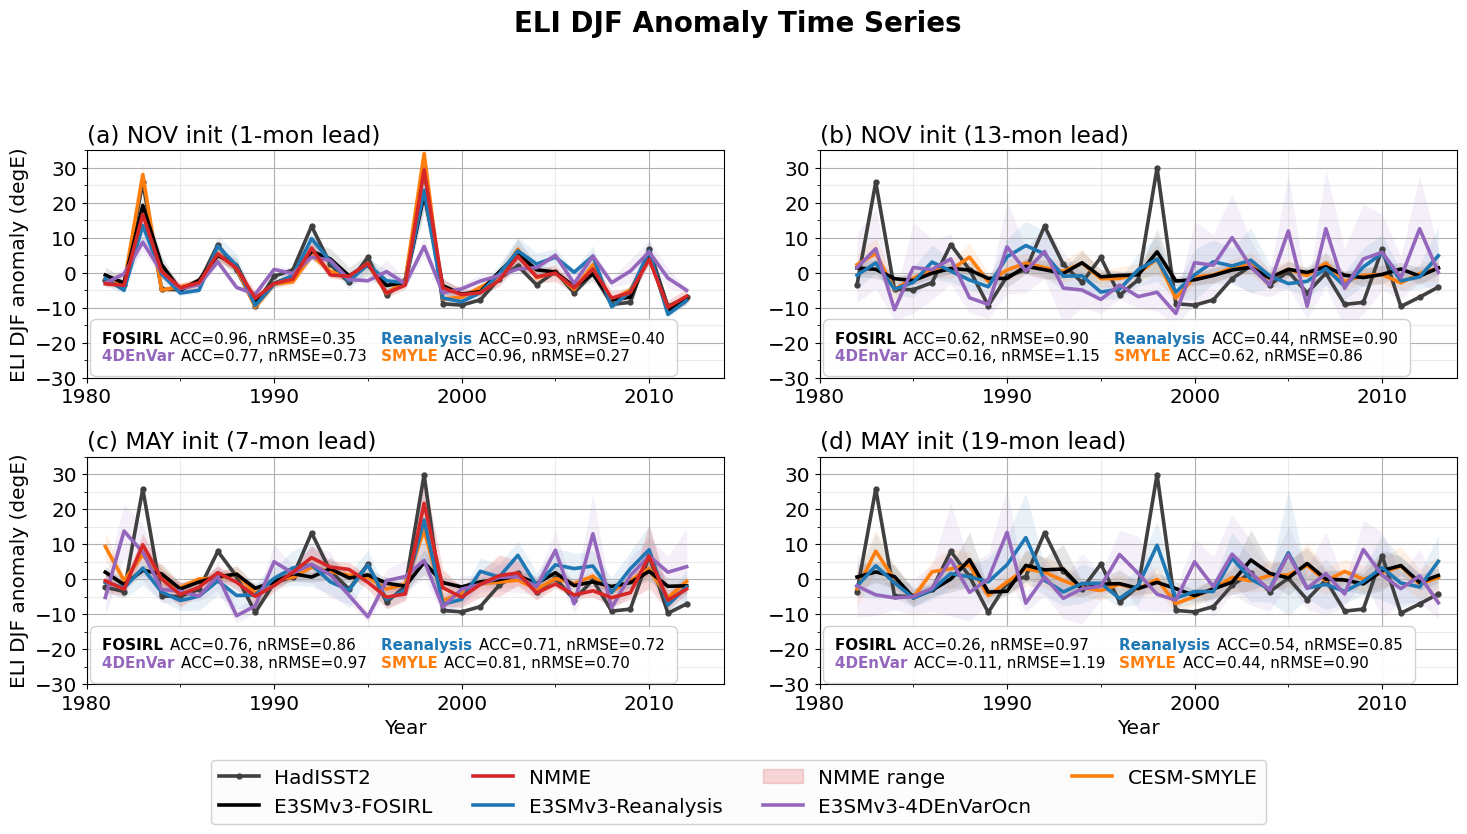

In [106]:
# -----------------------------
# Plot DJF seasonal ELI time series using the layout from 3a_sst_skill_ts.ipynb
# -----------------------------
plot_cfg = TIMESERIES_PLOT_CONFIG
nmme_style = NMME_STYLE
target_leads = plot_cfg["target_leads"]
plot_months = [
    month for month in plot_cfg["plot_months"]
    if month in INIT_MONTHS and month in target_leads
]
nrow, ncol = len(plot_months), plot_cfg["ncol"]
reference_model = next(iter(MODEL_SPECS))
display_target_years = np.concatenate([
    np.asarray(eli_seas_time[reference_model][month].sel(L=lead).dt.year.values, dtype=int)
    for month in plot_months for lead in target_leads[month]
])
plot_xmin = float(display_target_years.min()) - plot_cfg["axis_year_margin"]
plot_xmax = float(display_target_years.max()) + plot_cfg["axis_year_margin"]
major_step = plot_cfg["major_year_step"]
minor_step = plot_cfg["minor_year_step"]
major_years = np.arange(
    (display_target_years.min() // major_step) * major_step,
    display_target_years.max() + major_step,
    major_step,
)
major_years = major_years[(major_years >= plot_xmin) & (major_years <= plot_xmax)]
minor_years = np.arange(
    (display_target_years.min() // minor_step) * minor_step,
    display_target_years.max() + minor_step,
    minor_step,
)
minor_years = minor_years[(minor_years >= plot_xmin) & (minor_years <= plot_xmax)]

fontz = plot_cfg["font_size"]
title_fontz = fontz * plot_cfg["title_font_scale"]
tick_fontz = fontz * plot_cfg["tick_font_scale"]
legend_fontz = fontz * plot_cfg["legend_font_scale"]
annotation_fontz = fontz * plot_cfg["annotation_font_scale"]
fig_width = plot_cfg["fig_width"]
fig_height = plot_cfg["fig_height"]
line_width = plot_cfg["line_width"]

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})

fig = plt.figure(figsize=(fig_width, fig_height))
for row, month in enumerate(plot_months):
    for col, lead in enumerate(target_leads[month]):
        ax = fig.add_subplot(nrow, ncol, row * 2 + col + 1)
        reference_times = eli_seas_time[reference_model][month].sel(L=lead)
        target_years = np.asarray(reference_times.dt.year.values, dtype=float)
        target_times = np.asarray(reference_times.values, dtype=object)
        obs_values = eli_tools.observations_for_times(eli_obs_seas_anom, target_times)
        valid_obs = np.isfinite(target_years) & np.isfinite(obs_values)

        ax.plot(
            target_years[valid_obs], obs_values[valid_obs],
            color=plot_cfg["obs_color"],
            linewidth=line_width,
            marker=plot_cfg["obs_marker"],
            markersize=plot_cfg["obs_marker_size"],
            label="HadISST2",
        )

        metrics = {}
        for model, spec in MODEL_SPECS.items():
            values = eli_seas_dd[model][month].sel(L=lead)
            mean = values.mean("M")
            spread = values.std("M")
            valid_model = np.isfinite(target_years) & np.isfinite(mean.values)
            years_model = target_years[valid_model]
            mean_model = mean.values[valid_model]
            spread_model = spread.values[valid_model]
            linestyle = MODEL_LINESTYLES[model]

            ax.plot(
                years_model, mean_model,
                color=spec.color,
                linewidth=line_width,
                linestyle=linestyle,
                label=spec.label,
            )
            ax.fill_between(
                years_model,
                mean_model - spread_model,
                mean_model + spread_model,
                color=spec.color,
                alpha=plot_cfg["spread_alpha"],
                linewidth=0,
            )

            score = seasonal_skill[model][month].sel(L=lead)
            short_name = spec.label.replace("E3SMv3-", "").replace("Ocn", "")
            if model == "CESM-SMYLE":
                short_name = "SMYLE"
            metrics[model] = (short_name, float(score.acc), float(score.nrmse), spec.color)

        if month in nmme_eli_seas_timeseries and lead in nmme_eli_seas_timeseries[month]["values"].L.values:
            nmme_values = nmme_eli_seas_timeseries[month]["values"].sel(L=lead)
            nmme_times = nmme_eli_seas_timeseries[month]["time"].sel(L=lead)
            nmme_years = np.asarray(nmme_times.dt.year.values, dtype=float)
            nmme_model_means = nmme_values.mean("M", skipna=True)
            nmme_mean = nmme_model_means.mean("model", skipna=True)
            nmme_spread = nmme_model_means.std("model", skipna=True)
            nmme_valid = np.isfinite(nmme_years) & np.isfinite(nmme_mean.values)
            ax.plot(
                nmme_years[nmme_valid], nmme_mean.values[nmme_valid],
                color=nmme_style["color"], linewidth=line_width, linestyle=nmme_style["linestyle"],
                label=nmme_style["label"],
            )
            ax.fill_between(
                nmme_years[nmme_valid],
                (nmme_mean - nmme_spread).values[nmme_valid],
                (nmme_mean + nmme_spread).values[nmme_valid],
                color=nmme_style["color"], alpha=nmme_style["spread_alpha"], linewidth=0,
            )

        # Compact two-column verification badge, matching the 3a layout.
        if metrics:
            def _metric_item(name, acc, nrmse, color):
                name_area = TextArea(
                    f"{name} ",
                    textprops={"color": color, "fontweight": "bold", "fontsize": annotation_fontz},
                )
                value_area = TextArea(
                    f"ACC={acc:.2f}, nRMSE={nrmse:.2f}",
                    textprops={"color": "black", "fontsize": annotation_fontz},
                )
                return HPacker(children=[name_area, value_area], align="baseline", pad=0, sep=1)

            metric_column_keys = (
                ("E3SM-FOSIRL", "E3SM-4DEnVarOcn"),
                ("E3SM-Reanalysis", "CESM-SMYLE"),
            )
            metric_columns = [
                VPacker(
                    children=[_metric_item(*metrics[key]) for key in keys if key in metrics],
                    align="left", pad=0, sep=2,
                )
                for keys in metric_column_keys
                if any(key in metrics for key in keys)
            ]
            metric_box = AnchoredOffsetbox(
                loc=plot_cfg["annotation_loc"],
                child=HPacker(children=metric_columns, align="top", pad=0, sep=10),
                pad=0.3, frameon=True,
                bbox_to_anchor=plot_cfg["annotation_bbox"],
                bbox_transform=ax.transAxes, borderpad=0.0,
            )
            metric_box.patch.set_boxstyle("round,pad=0.3")
            metric_box.patch.set(**plot_cfg["annotation_box"])
            metric_box.set_zorder(7)
            ax.add_artist(metric_box)

        lead_months = int(lead) - 2
        figlabel = plot_cfg["figlabs"][row][col] if len(plot_months) == 2 else f"({chr(97 + row * 2 + col)})"
        ax.set_title(
            f"{figlabel} {plot_cfg['hindcast_labels'].get(month, f'{month:02d}')} init ({lead_months}-mon lead)",
            loc="left",
            fontsize=title_fontz,
        )
        ax.set_xticks(major_years)
        ax.set_xticks(minor_years, minor=True)
        ax.set_xlim([plot_xmin, plot_xmax])
        ax.set_ylim(plot_cfg["plot_ylim"])
        ax.set_yticks(plot_cfg["major_yticks"])
        ax.set_yticks(plot_cfg["minor_yticks"], minor=True)
        ax.tick_params(axis="both", labelsize=tick_fontz)
        ax.grid(plot_cfg["show_major_grid"], which="major")
        ax.grid(True, which="minor", alpha=plot_cfg["minor_grid_alpha"])
        if col == 0:
            ax.set_ylabel(plot_cfg["ylabel"], fontsize=tick_fontz)
        if row == nrow - 1:
            ax.set_xlabel(plot_cfg["xlabel"], fontsize=tick_fontz)

legend_entries = {}
for ax in fig.axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_entries.setdefault(label, handle)
if any(month in nmme_eli_seas_timeseries for month in plot_months):
    legend_entries.setdefault(
        "NMME range",
        mpatches.Patch(color=nmme_style["color"], alpha=nmme_style["spread_alpha"]),
    )
legend_order = [
    "HadISST2", nmme_style["label"], "NMME range", "CESM-SMYLE",
    "E3SMv3-FOSIRL", "E3SMv3-Reanalysis", "E3SMv3-4DEnVarOcn",
]
labels = [label for label in legend_order if label in legend_entries]
handles = [legend_entries[label] for label in labels]

def _reorder_legend_row_major(handle_list, label_list, ncol):
    if len(handle_list) <= ncol:
        return handle_list, label_list
    nrow = (len(handle_list) + ncol - 1) // ncol
    grid = [
        list(zip(handle_list, label_list))[row * ncol:(row + 1) * ncol]
        for row in range(nrow)
    ]
    reordered = [grid[row][col] for col in range(ncol) for row in range(nrow) if col < len(grid[row])]
    return [item[0] for item in reordered], [item[1] for item in reordered]

handles, labels = _reorder_legend_row_major(
    handles, labels, plot_cfg["legend_ncol"]
)
fig.legend(
    handles, labels,
    loc=plot_cfg["legend_loc"],
    ncol=plot_cfg["legend_ncol"],
    bbox_to_anchor=plot_cfg["legend_bbox"],
    frameon=True,
    facecolor=plot_cfg["legend_facecolor"],
    edgecolor=plot_cfg["legend_edgecolor"],
    framealpha=plot_cfg["legend_framealpha"],
    fontsize=legend_fontz,
)
fig.suptitle(
    plot_cfg["title"],
    fontsize=fontz * 1.25,
    fontweight="bold",
    y=plot_cfg["suptitle_y"],
)
fig.tight_layout(rect=plot_cfg["layout_rect"])
figpath = FIGURE_OUTDIR / figure_filename(*plot_cfg["filename_parts"], ext=plot_cfg["figfmt"])
mov.save_figure(
    fig, figpath,
    mode="",
    metric=plot_cfg["metric"],
    title=plot_cfg["title"],
    caption=(
        f"Displayed initialization years: {START_YEAR}-{END_YEAR}; "
        f"primary-system annotations use common cohorts; NMME skill period {NMME_PERIOD_TAG}"
    ),
    dpi=plot_cfg["dpi"],
)
print("Saved figure:", figpath)
plt.show()


## Clean up


In [107]:
# Release lazy NetCDF handles and this notebook's Dask resources.
close_notebook_resources(globals())
print("Closed ELI datasets and Dask resources.")


Closed ELI datasets and Dask resources.
